In [80]:
import os
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIGURAR / ADAPTAR ...
host = "localhost"
port = 3306
user = "root"
password = ""
database = "faculdade"

conn = pymysql.connect(
    host=host,
    port=int(port),
    user=user,
    passwd=password,
    db=database,
    charset='utf8mb4')

# ADAPTAR
df = pd.read_sql_query("SELECT * FROM aluno", conn)

df.tail()

C:\Users\erica\AppData\Local\Temp\ipykernel_20220\784420033.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM aluno", conn)


,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
1755,2019869,Alice,Laranjeira,Informática,11.0,1,17.0
1756,20221093,Patrícia,Pereira,Comunicação,14.0,1,16.0
1757,20071160,Lucas,Capicua,Informática,12.0,1,20.0
1758,2020288,Pedro,Capicua,Comunicação,13.0,1,19.0
1759,2019163820,Diana,da Silva,Comunicação,13.0,1,18.0


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nr_aluno         1760 non-null   int64  
 1   nome             1760 non-null   str    
 2   apelido          1760 non-null   str    
 3   curso            1756 non-null   str    
 4   media_entrada    1760 non-null   float64
 5   curso_concluido  1760 non-null   int64  
 6   media_final      1743 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 96.4 KB


In [82]:
df.describe()

,nr_aluno,media_entrada,curso_concluido,media_final
count,1.760000e+03,1760.000000,1760.000000,1743.000000
mean,6.892892e+07,15.031818,0.991477,14.876076
std,3.213189e+08,3.398510,0.091950,3.464535
min,2.021600e+04,-20.000000,0.000000,-20.000000
25%,2.019510e+06,12.000000,1.000000,12.000000
50%,2.022526e+06,15.000000,1.000000,15.000000
75%,2.020136e+07,18.000000,1.000000,18.000000
max,2.022174e+09,22.000000,1.000000,21.000000


In [83]:
df.head()

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
0,20031358,Leonardo,Pires,Psicologia,15.0,1,16.0
1,2022158,Raquel,Laranjeira,Informática,17.0,1,11.0
2,2003812,Anne,Silva,Informática,16.0,1,16.0
3,2022901,Patrícia,Castelo-Branco,Informática,11.0,1,17.0
4,2019303,Avelino,Sampaio,Comunicação,13.0,1,18.0


In [84]:
for col in df.columns:
    print(df[col].value_counts(ascending = True, dropna=False))
    print("\n")

nr_aluno
20031358      1
2022158       1
2003812       1
2022901       1
2019303       1
             ..
2019869       1
20221093      1
20071160      1
2020288       1
2019163820    1
Name: count, Length: 1760, dtype: int64


nome
Thomas Anderson       1
Anakin Skywalker      1
Luke                  1
Alf                   1
Sininho               1
Beatriz              38
Diana                44
Catarina             47
Raquel               48
Joana                48
Ana                  49
Patrícia             51
Marta                51
Carla                51
Olivia               51
Maria                55
Leonardo             58
Maria João           58
Alice                59
Sandra               62
Rui                  62
Anne                 63
Christos             71
Michaelangelo        71
Bruno                71
Lucas                71
Nuno                 74
Miguel               75
Pedro                76
Jorge                78
Avelino              79
Rodrigo              79


In [85]:
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum()}')

nr_aluno: 0
nome: 0
apelido: 0
curso: 4
media_entrada: 0
curso_concluido: 0
media_final: 17


In [86]:
df[df['curso'].isnull()]

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
26,20031371,Leonardo,Cintra,NaN,10.0,1,18.0
28,2021840,Sandra,Pires,NaN,11.0,1,19.0
36,2003995,Nuno,Silva,NaN,16.0,1,15.0
41,2020392,Bruno,Castelo-Branco,NaN,19.0,1,11.0


In [87]:
df[df['curso'].isin(['Informática', 'Psicologia', 'Comunicação'])]

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
0,20031358,Leonardo,Pires,Psicologia,15.0,1,16.0
1,2022158,Raquel,Laranjeira,Informática,17.0,1,11.0
2,2003812,Anne,Silva,Informática,16.0,1,16.0
3,2022901,Patrícia,Castelo-Branco,Informática,11.0,1,17.0
4,2019303,Avelino,Sampaio,Comunicação,13.0,1,18.0
...,...,...,...,...,...,...,...
1755,2019869,Alice,Laranjeira,Informática,11.0,1,17.0
1756,20221093,Patrícia,Pereira,Comunicação,14.0,1,16.0
1757,20071160,Lucas,Capicua,Informática,12.0,1,20.0
1758,2020288,Pedro,Capicua,Comunicação,13.0,1,19.0


Text(0.5, 1.0, 'Média de Entrada vs Média Final')

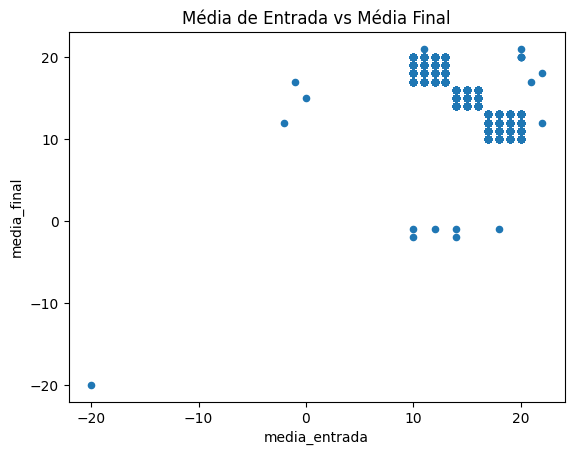

In [88]:
df.plot(x='media_entrada', y='media_final', kind='scatter')
plt.title('Média de Entrada vs Média Final')


In [89]:
df.corr(numeric_only=True) # incluir no relatorio a correlação considerando todos e considerando apenas os válidos

,nr_aluno,media_entrada,curso_concluido,media_final
nr_aluno,1.000000,0.025724,0.017287,-0.021043
media_entrada,0.025724,1.000000,0.022699,-0.696457
curso_concluido,0.017287,0.022699,1.000000,NaN
media_final,-0.021043,-0.696457,NaN,1.000000


In [90]:
df.groupby('curso').agg({'media_final': 'mean'})

,media_final
curso,
Cintilar,-20.000000
Comunicação,15.048301
Desconhecido,15.500000
Informática,14.902062
Medicina Veterinária,16.000000
Má Vida,20.000000
Psicologia,14.722034


In [91]:
def separar_dados(df: pd.DataFrame,
                  caminho_validos: str = r"C:\Users\erica\Documents\Mestrado\Projetos\Eng_Dados\Escola_Proj\data\processed\dados_validos.csv",
                  caminho_invalidos: str = r"C:\Users\erica\Documents\Mestrado\Projetos\Eng_Dados\Escola_Proj\data\processed\dados_invalidos.csv"):

    cursos_permitidos = {"Informática", "Psicologia", "Comunicação"}
    concluido = df["curso_concluido"].astype(str).str.strip() == "1"

    invalido = (
        df["curso"].isna() |
        ~df["curso"].isin(cursos_permitidos) |
        ~df["media_entrada"].between(10, 20) |
        (concluido & df["media_final"].isna()) |
        (df["media_final"].notna() & ~df["media_final"].between(10, 20))
    )

    df[~invalido].to_csv(caminho_validos, index=False, encoding="utf-8-sig")
    df[invalido].to_csv(caminho_invalidos, index=False, encoding="utf-8-sig")

    return df[~invalido], df[invalido]

In [92]:
df_validos, df_invalidos = separar_dados(df)

In [93]:
df_validos

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
0,20031358,Leonardo,Pires,Psicologia,15.0,1,16.0
1,2022158,Raquel,Laranjeira,Informática,17.0,1,11.0
2,2003812,Anne,Silva,Informática,16.0,1,16.0
3,2022901,Patrícia,Castelo-Branco,Informática,11.0,1,17.0
4,2019303,Avelino,Sampaio,Comunicação,13.0,1,18.0
...,...,...,...,...,...,...,...
1755,2019869,Alice,Laranjeira,Informática,11.0,1,17.0
1756,20221093,Patrícia,Pereira,Comunicação,14.0,1,16.0
1757,20071160,Lucas,Capicua,Informática,12.0,1,20.0
1758,2020288,Pedro,Capicua,Comunicação,13.0,1,19.0


In [94]:
df_validos.info()

<class 'pandas.DataFrame'>
Index: 1732 entries, 0 to 1759
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nr_aluno         1732 non-null   int64  
 1   nome             1732 non-null   str    
 2   apelido          1732 non-null   str    
 3   curso            1732 non-null   str    
 4   media_entrada    1732 non-null   float64
 5   curso_concluido  1732 non-null   int64  
 6   media_final      1717 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 108.2 KB


In [95]:
df_validos.describe()

,nr_aluno,media_entrada,curso_concluido,media_final
count,1.732000e+03,1732.000000,1732.000000,1717.000000
mean,6.991812e+07,15.071016,0.991339,14.936517
std,3.238104e+08,3.218795,0.092685,3.225958
min,2.021600e+04,10.000000,0.000000,10.000000
25%,2.019510e+06,12.000000,1.000000,12.000000
50%,2.022548e+06,15.000000,1.000000,15.000000
75%,2.020136e+07,18.000000,1.000000,18.000000
max,2.022174e+09,20.000000,1.000000,20.000000


In [96]:
df_invalidos

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
26,20031371,Leonardo,Cintra,NaN,10.0,1,18.0
28,2021840,Sandra,Pires,NaN,11.0,1,19.0
29,2003594,Michaelangelo,Laranjeira,Comunicação,0.0,1,15.0
31,2021715,Avelino,da Silva,Desconhecido,16.0,1,15.0
32,202211,Catarina,Morais,Comunicação,20.0,1,21.0
34,2019990,Leonardo,Capicua,Comunicação,22.0,1,12.0
35,2021320,Jorge,Pires,Medicina Veterinária,17.0,1,11.0
36,2003995,Nuno,Silva,NaN,16.0,1,15.0
37,2020264,Miguel,Pires,Medicina Veterinária,13.0,1,20.0
41,2020392,Bruno,Castelo-Branco,NaN,19.0,1,11.0


In [97]:
for col in df_validos.columns:
    print(f'{col}: {df_validos[col].isnull().sum()}')

nr_aluno: 0
nome: 0
apelido: 0
curso: 0
media_entrada: 0
curso_concluido: 0
media_final: 15


In [98]:
for col in df_validos.columns:
    print(df_validos[col].value_counts(ascending = True, dropna=False))
    print("\n")

nr_aluno
20031358      1
2022158       1
2003812       1
2022901       1
2019303       1
             ..
2019869       1
20221093      1
20071160      1
2020288       1
2019163820    1
Name: count, Length: 1732, dtype: int64


nome
Thomas Anderson       1
Anakin Skywalker      1
Luke                  1
Beatriz              38
Diana                43
Catarina             46
Ana                  47
Raquel               48
Joana                48
Patrícia             51
Marta                51
Carla                51
Olivia               51
Maria                55
Leonardo             56
Maria João           58
Alice                59
Sandra               61
Rui                  61
Anne                 62
Lucas                69
Michaelangelo        69
Bruno                69
Nuno                 71
Christos             71
Miguel               72
Pedro                75
Jorge                76
Avelino              78
Rodrigo              79
Rita                114
Name: count, dtype: int6

In [99]:
df_validos.corr(numeric_only=True)

,nr_aluno,media_entrada,curso_concluido,media_final
nr_aluno,1.000000,0.024948,0.017579,-0.026315
media_entrada,0.024948,1.000000,0.025300,-0.880122
curso_concluido,0.017579,0.025300,1.000000,NaN
media_final,-0.026315,-0.880122,NaN,1.000000


Text(0.5, 1.0, 'Média de Entrada vs Média Final')

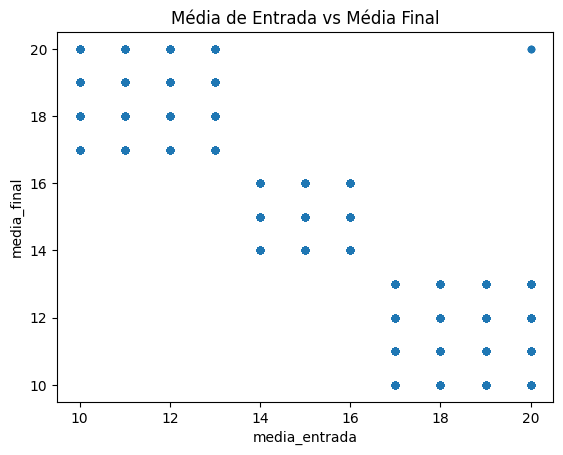

In [100]:
df_validos.plot(x='media_entrada', y='media_final', kind='scatter')
plt.title('Média de Entrada vs Média Final')


In [101]:
# descobrir quem é o aluno que é o outlier
# nota de entrada 20 e nota final 20

df_validos[(df_validos['media_entrada'] == 20) & (df_validos['media_final'] == 20)]

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
100,2210000,Thomas Anderson,(Neo),Informática,20.0,1,20.0
201,2290110,Anakin Skywalker,(Lord Vader),Psicologia,20.0,1,20.0
302,2210100,Luke,Skywalker,Comunicação,20.0,1,20.0


Text(0, 0.5, 'Contagem')

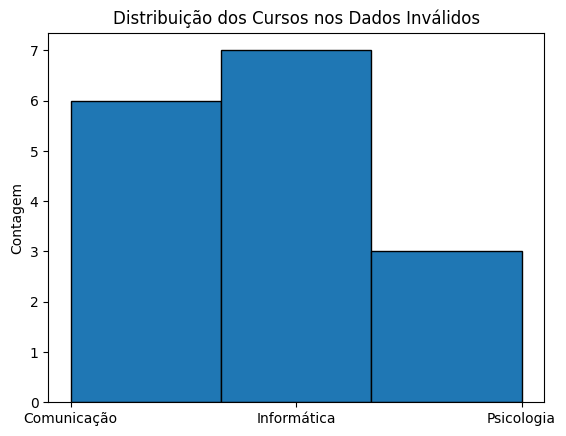

In [102]:
## quantos alunos dos cursos de informática, psicologia e comunicação estão nos dados válidos?
# fazer histograma com os 3 cursos

fig, ax= plt.subplots()
ax.hist(df_invalidos['curso'][df_invalidos['curso'].isin(['Informática', 'Psicologia', 'Comunicação'])], bins=3, edgecolor='black')
plt.title('Distribuição dos Cursos nos Dados Inválidos')
plt.ylabel('Contagem')

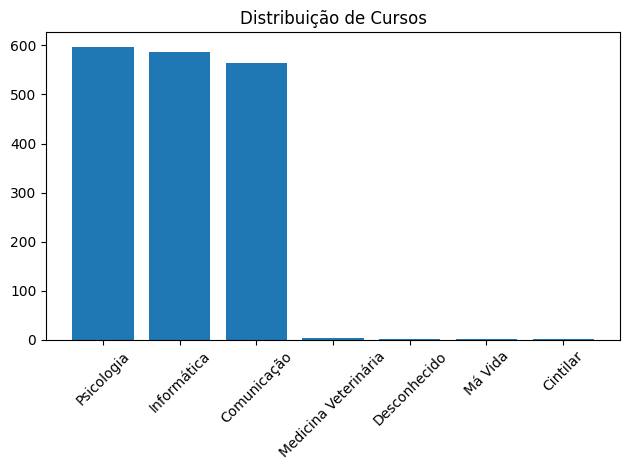

In [103]:
fig, ax = plt.subplots()
ax.bar(df['curso'].value_counts().index, df['curso'].value_counts().values)
ax.set_title('Distribuição de Cursos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



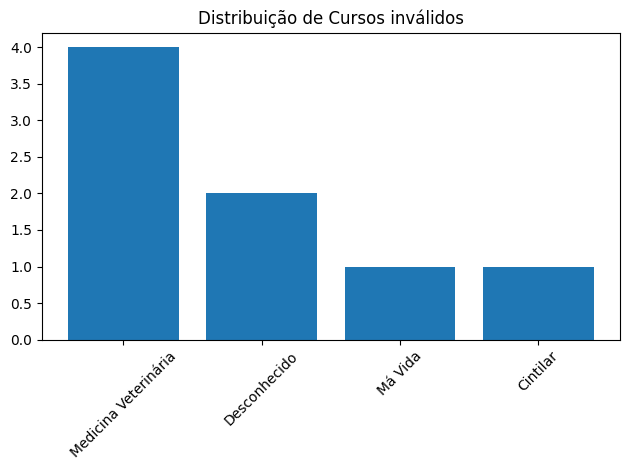

In [104]:
df_filtrado = df[~df['curso'].isin(['Informática', 'Psicologia', 'Comunicação'])]

fig, ax = plt.subplots()
ax.bar(
    df_filtrado['curso'].value_counts().index,
    df_filtrado['curso'].value_counts().values
)
ax.set_title('Distribuição de Cursos inválidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

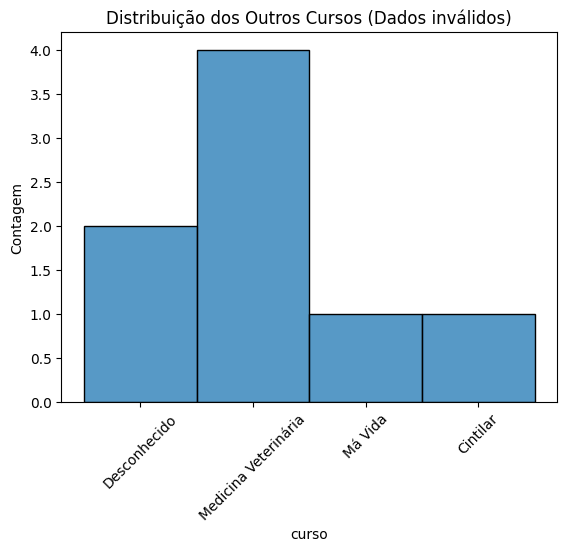

In [105]:

df_filtrado2 = df[df['curso'].isin(df_filtrado['curso'].unique())]

plt.figure()
sns.histplot(data=df_filtrado2, x='curso')
plt.title('Distribuição dos Outros Cursos (Dados inválidos)')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

In [106]:
## dados validos: histograma de distribuição de notas com 5 bins, um pra todos os cursos e um por curso

Text(0.5, 0, 'Média Final')

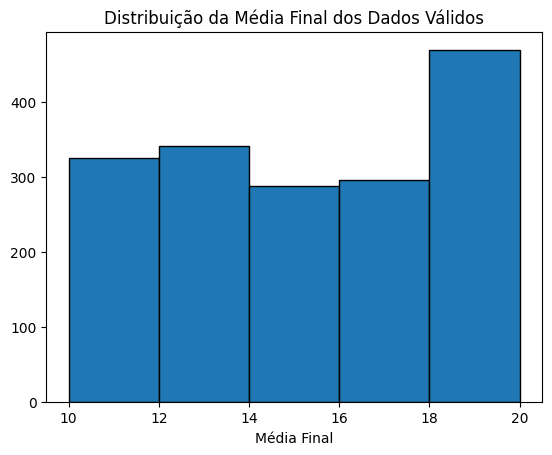

In [107]:
fig, ax = plt.subplots()
ax.hist(df_validos['media_final'], bins=5, edgecolor='black')
plt.title('Distribuição da Média Final dos Dados Válidos')
plt.xlabel('Média Final')

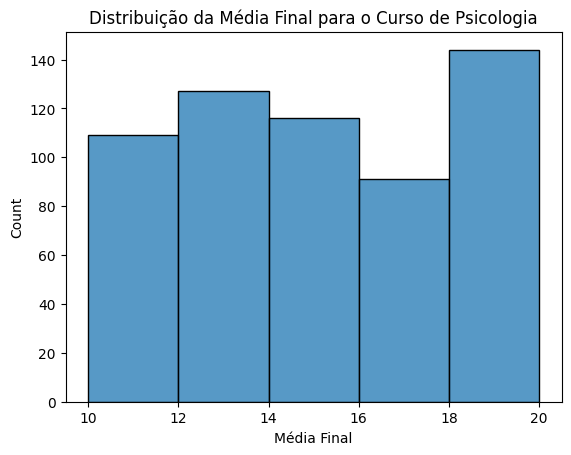

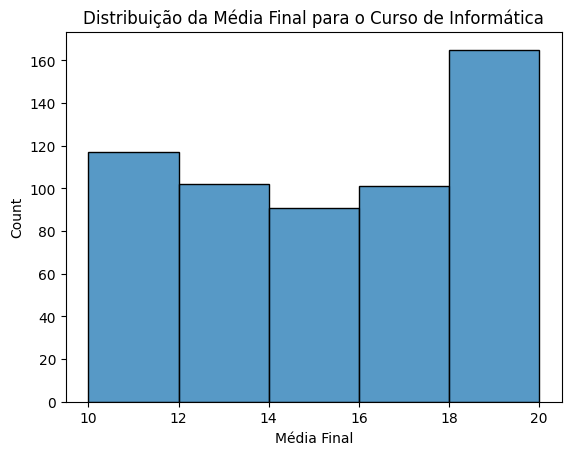

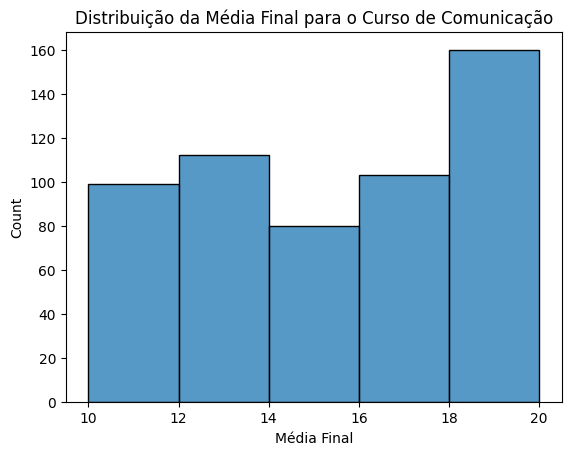

In [108]:
for curso in df_validos['curso'].unique():
    plt.figure()
    sns.histplot(data=df_validos[df_validos['curso'] == curso], x='media_final', bins=5, edgecolor='black')
    plt.title(f'Distribuição da Média Final para o Curso de {curso}')
    plt.xlabel('Média Final')
    plt.show()

In [114]:
origem = pd.read_csv(r"C:\Users\erica\Documents\Mestrado\Projetos\Eng_Dados\Escola_Proj\data\raw\dados_origem_alunos.csv")
origem.head()

,NR_ALUNO,CURSO_ORIGEM
0,20216,Profissional
1,200315,Geral
2,200321,Profissional
3,200326,Profissional
4,200332,Profissional


In [117]:
df_com_origem = df_validos.join(origem.set_index('NR_ALUNO'), on='nr_aluno', how='left', rsuffix='_origem')

df_com_origem.head()

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final,CURSO_ORIGEM
0,20031358,Leonardo,Pires,Psicologia,15.0,1,16.0,Geral
1,2022158,Raquel,Laranjeira,Informática,17.0,1,11.0,Geral
2,2003812,Anne,Silva,Informática,16.0,1,16.0,Geral
3,2022901,Patrícia,Castelo-Branco,Informática,11.0,1,17.0,Geral
4,2019303,Avelino,Sampaio,Comunicação,13.0,1,18.0,Profissional


In [118]:
df_com_origem.info()

<class 'pandas.DataFrame'>
Index: 1732 entries, 0 to 1759
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nr_aluno         1732 non-null   int64  
 1   nome             1732 non-null   str    
 2   apelido          1732 non-null   str    
 3   curso            1732 non-null   str    
 4   media_entrada    1732 non-null   float64
 5   curso_concluido  1732 non-null   int64  
 6   media_final      1717 non-null   float64
 7    CURSO_ORIGEM    1711 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 121.8 KB


In [139]:
def separar_dados_com_origem(df: pd.DataFrame,
                  caminho_validos: str = r"C:\Users\erica\Documents\Mestrado\Projetos\Eng_Dados\Escola_Proj\data\processed\dados_validos_com_origem.csv",
                  caminho_invalidos: str = r"C:\Users\erica\Documents\Mestrado\Projetos\Eng_Dados\Escola_Proj\data\processed\dados_invalidos_com_origem.csv"):

    invalido = df[" CURSO_ORIGEM"].isna()

    df[~invalido].to_csv(caminho_validos, index=False, encoding="utf-8-sig")
    df[invalido].to_csv(caminho_invalidos, index=False, encoding="utf-8-sig")

    return df[~invalido], df[invalido]

In [140]:
df_origem_v, df_origem_i = separar_dados_com_origem(df_com_origem)

In [141]:
df_origem_i

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final,CURSO_ORIGEM
54,202247,Olivia,Pires,Informática,12.0,1,20.0,NaN
68,2003504,Beatriz,Laranjeira,Comunicação,12.0,0,NaN,NaN
154,2003177,Olivia,da Silva,Psicologia,10.0,1,18.0,NaN
280,201985,Ana,da Silva,Comunicação,17.0,1,13.0,NaN
315,202219,Christos,Machado,Comunicação,20.0,1,11.0,NaN
360,2003269,Joana,Morais,Comunicação,15.0,1,16.0,NaN
394,200331,Beatriz,Castelo,Comunicação,19.0,1,12.0,NaN
550,2003268,Michaelangelo,Capicua,Psicologia,13.0,1,20.0,NaN
558,202035,Michaelangelo,Laranjeira,Informática,17.0,1,12.0,NaN
614,2003289,Leonardo,Cintra,Psicologia,14.0,1,14.0,NaN


In [142]:
df_origem_v.info()

<class 'pandas.DataFrame'>
Index: 1711 entries, 0 to 1759
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nr_aluno         1711 non-null   int64  
 1   nome             1711 non-null   str    
 2   apelido          1711 non-null   str    
 3   curso            1711 non-null   str    
 4   media_entrada    1711 non-null   float64
 5   curso_concluido  1711 non-null   int64  
 6   media_final      1697 non-null   float64
 7    CURSO_ORIGEM    1711 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 120.3 KB
